In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter



# Load the data
base_dir = Path.cwd().parent.parent
data_path = base_dir / "data" / "processed" 

#df = pd.read_csv(data_path / "combined_listings.csv")
df = pd.read_csv(data_path / "combined_sold_all.csv")


/var/folders/dc/245wkwwd22jf9mtnyn_s6_pr0000gn/T/ipykernel_96868/604101191.py:14: DtypeWarning: Columns (0: WaterfrontYN, 1: BuyerAgencyCompensationType, 2: latfilled, 3: lonfilled, 4: BuyerAgentAOR, 5: ListAgentAOR, 6: OriginatingSystemName, 7: OriginatingSystemSubName) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path / "combined_sold_all.csv")


### What is the Residential vs. other property type share?

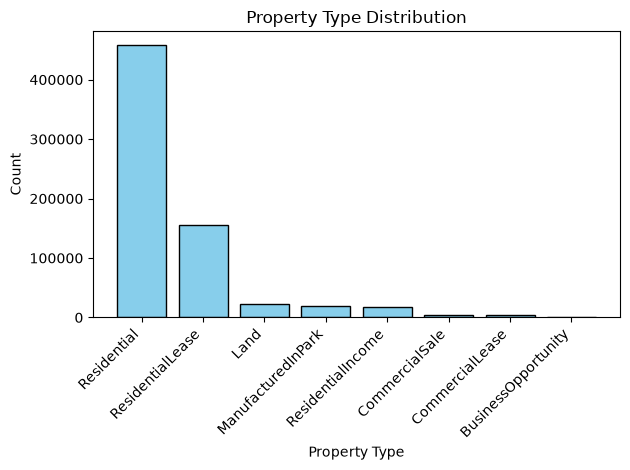

Residential: 458336 (67.24%)
ResidentialLease: 155507 (22.82%)
Land: 22601 (3.32%)
ManufacturedInPark: 18604 (2.73%)
ResidentialIncome: 18212 (2.67%)
CommercialSale: 4267 (0.63%)
CommercialLease: 3599 (0.53%)
BusinessOpportunity: 473 (0.07%)


In [3]:
count = df['PropertyType'].value_counts()
total = count.sum()

plt.bar(count.index, count.values, color='skyblue', edgecolor='black')

plt.xticks(rotation=45, ha='right')

plt.title('Property Type Distribution')
plt.xlabel('Property Type')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

for property_type, count in count.items():
    percentage = (count / total) * 100
    print(f"{property_type}: {count} ({percentage:.2f}%)")

### What are the median and average close prices?

In [4]:
cc = df['ClosePrice']
print(f"Average Price: ${cc.mean():.2f}")
print(f"Median Price: ${cc.median():.2f}")

Average Price: $874768.47
Median Price: $629000.00


### What does the Days on Market distribution look like?

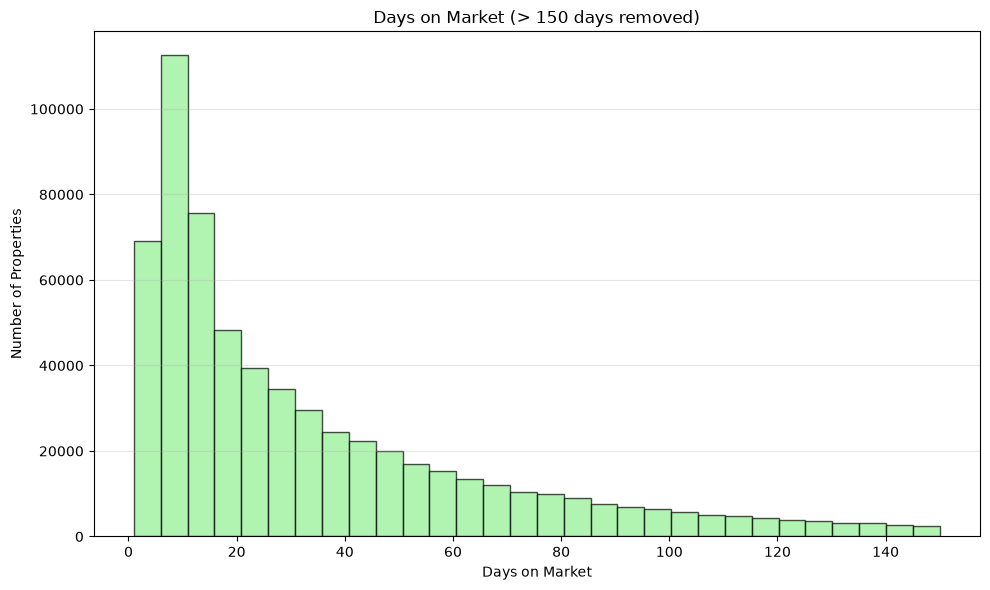

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

dom = df['DaysOnMarket']
dom = dom[dom > 0].dropna()

dom_filtered = dom[dom <= 150]

# 4. Plot
plt.figure(figsize=(10, 6))
plt.hist(dom_filtered, bins=30, color='lightgreen', edgecolor='black', alpha=0.7)

plt.title(f'Days on Market (> 150 days removed)')
plt.xlabel('Days on Market')
plt.ylabel('Number of Properties')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### What percentage of homes sold above vs. below list price?

In [6]:
lp = df['ListPrice']
sp = df['ClosePrice']
total_sold = len(sp)

above_list_price = (sp > lp).sum()
percentage_above_list_price = (above_list_price / total_sold) * 100

below_list_price = (sp < lp).sum()
percentage_below_list_price = (below_list_price / total_sold) * 100

at_list_price = (sp == lp).sum()
percentage_at_list_price = (at_list_price / total_sold) * 100

print(f"Properties sold above list price: {above_list_price} ({percentage_above_list_price:.2f}%)")
print(f"Properties sold below list price: {below_list_price} ({percentage_below_list_price:.2f}%)")
print(f"Properties sold at list price: {at_list_price} ({percentage_at_list_price:.2f}%)")

Properties sold above list price: 212075 (31.11%)
Properties sold below list price: 259533 (38.08%)
Properties sold at list price: 208952 (30.66%)


### Are there any apparent date consistency issues (e.g., close date before listing date)?

In [7]:
invalid = df.loc[df['DaysOnMarket'] < 0, 'DaysOnMarket'].count()
print(f"Number of properties with negative DaysOnMarket: {invalid}")

Number of properties with negative DaysOnMarket: 86


### Which counties have the highest median prices?

In [ ]:
cp = df['ClosePrice']
ct = df['CountyOrParish'].unique()

county_avg_prices = df.groupby('CountyOrParish')['ClosePrice'].mean().sort_values(ascending=False)
print("\nTop 5 Counties by Average Close Price:")
for i in range(0,5):
    county = county_avg_prices.index[i]
    avg_price = county_avg_prices.iloc[i]
    print(f"County: {county}, Average Close Price: ${avg_price:.2f}")


Top 5 Counties by Average Close Price:
County: Other County, Average Close Price: $9549260.83
County: San Mateo, Average Close Price: $1799992.63
County: Imperial, Average Close Price: $1758079.54
County: Santa Clara, Average Close Price: $1740538.03
County: Santa Barbara, Average Close Price: $1469273.82
